# Анализ факторов, влияющих на длительность госпитализации пациентов медицинского центра

**Описание проекта**

В проекте используются данные федерального медицинского центра ФГБОУ ВО СПбГПМУ. Датасет содержит сведения о пациентах, датах поступления и выписки, регионе проживания, отделении, профиле лечения, источнике финансирования, количестве койко-дней, типе поступления и диагнозах по МКБ.

Анализ направлен на изучение длительности лечения пациентов в стационаре. Особое внимание уделяется выявлению различий между отделениями, оценке сезонной динамики поступлений и проверке статистических гипотез о средней продолжительности 

**Цель проекта**

На основе данных федерального медицинского центра ФГБОУ ВО СПбГПМУ проанализировать длительность госпитализации пациентов и определить факторы, которые могут влиять на время лечения в стационаре.

В рамках проекта необходимо:

1. Подготовить данные к анализу: обработать пропуски, дубликаты и типы данных.
2. Изучить распределение длительности госпитализации пациентов.
3. Определить отделения с наибольшей средней длительностью госпитализации.
4. Проанализировать динамику поступления пациентов по месяцам.
5. Проверить статистические гипотезы о длительности госпитализации.

# Описание данных
В работе использовалась таблица, в которой представлены данные о случаях госпитализации пациентов медицинского центра ФГБОУ ВО СПбГПМУ

## Шаг 1. Загрузка данных
Загрузим все необходимые данные и ознакомимся с содержанием таблиц.

### Задача 1.1 Импорт библиотек
Загружаем необходимые для работы библиотеки

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st
import numpy as np

### Задача 1.2 Чтение данных
Прочитаем и сохраним данные в отдельный датафрейм

In [2]:
df_hospital = pd.read_csv('/datasets/hospital.csv')

# Проверяем первые строки
df_hospital.head()

display(df_hospital)

,ДАТА_ПОСТУПЛЕНИЯ,ДАТА_ВЫПИСКИ,УНИКАЛЬНЫЙ_ID,НОМЕР_ИБ,ШИФР,РЕГИОН,ПЛАТЕЛЬЩИК,ИСТОЧНИК_ФИНАНСИРОВАНИЯ,ОТДЕЛЕНИЕ,ПРОФИЛЬ,КОЙКО_ДНИ,ПЛАНОВО_ЭКСТРЕННО,КОД_МКБ_ПРИ_ПОСТУПЛЕНИИ,КОД_МКБ_ПРИ_ВЫПИСКЕ
0,01.01.2019,10.01.2019,858042000,1,5.4.1,NaN,"ОАО ""ГСМК"" СПб",ОМС,Микрохирургическое отделение,Сосудистой хирургии,10.0,Экстренная,S61.7,S66.4
1,01.01.2019,01.01.2019,993109000,3,5.13.1,NaN,"СПб филиал ООО ""СМК РЕСО - Мед""",ОМС,Хирургическое отделение №3,Гнойные хирургические,1.0,Экстренная,K37,K63.8
2,01.01.2019,01.01.2019,993111000,4,5.12.1,NaN,"ООО ""Капитал Медицинское Страхование""",ОМС,Хирургическое отделение №3,Гнойные хирургические,1.0,Экстренная,K37,K63.8
3,01.01.2019,07.01.2019,993110000,2,5.4.1,NaN,"ОАО ""ГСМК"" СПб",ОМС,Инфекционное отделение №1,Инфекционные,7.0,Экстренная,B27.9,J03.9
4,01.01.2019,05.01.2019,987185000,5,1.1.1,NaN,Коммерческие,Наличный расчет,ПЦ Акушерское физиологическое отделение,Для беременных и рожениц,5.0,Плановая,O42.9,O82.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125256,30.12.2023,31.12.2023,714221000,38557,5.666.0,NaN,ОМС 86 Регион,ОМС,Хирургическое отделение №3,Хирургические для детей,2.0,Экстренная,L02.8,L02.8
125257,30.12.2023,06.01.2024,1258807000,38558,5.12.1,Ульяновская обл.,"ООО ""Капитал Медицинское Страхование""",ОМС,Инфекционное отделение №1,Инфекционные,8.0,Экстренная,J01.9,J06.8
125258,30.12.2023,26.01.2024,1258810000,38560,5.666.1,NaN,ОМС 86 Регион,ОМС,Гастроэнтерологическое отделение,Гастроэнтерологические,28.0,Плановая,K75.4,K73.2
125259,30.12.2023,30.12.2023,1258811000,38561,5.666.0,NaN,ОМС 86 Регион,ОМС,ПЭМП ДПО,Хирургические для детей,1.0,Экстренная,K59.0,K59.0


## Шаг 2. Предобработка данных

Выведем название столбцов

In [3]:
df_hospital.columns

Index(['ДАТА_ПОСТУПЛЕНИЯ', 'ДАТА_ВЫПИСКИ', 'УНИКАЛЬНЫЙ_ID', 'НОМЕР_ИБ', 'ШИФР',
       'РЕГИОН', 'ПЛАТЕЛЬЩИК', 'ИСТОЧНИК_ФИНАНСИРОВАНИЯ', 'ОТДЕЛЕНИЕ',
       'ПРОФИЛЬ', 'КОЙКО_ДНИ', 'ПЛАНОВО_ЭКСТРЕННО', 'КОД_МКБ_ПРИ_ПОСТУПЛЕНИИ',
       'КОД_МКБ_ПРИ_ВЫПИСКЕ'],
      dtype='object')

Сейчас названия столбцов слишком длинные и сложные, из-за чего трудно читать код и работать с ним. Приведем названия к стандартному виду

### Задача 2.1 Переименование колонок

Переведем все названия на английский и запишем их в формате **snake_case**: нижний регистр, слова разделены нижним подчёркиванием — `_`.

In [4]:
df_hospital.rename(columns={
    'ДАТА_ПОСТУПЛЕНИЯ': 'income_date',
    'ДАТА_ВЫПИСКИ': 'outcome_date',
    'УНИКАЛЬНЫЙ_ID': 'user_id',
    'НОМЕР_ИБ': 'is_num',
    'ШИФР': 'code',
    'РЕГИОН': 'region',
    'ПЛАТЕЛЬЩИК': 'payer',
    'ИСТОЧНИК_ФИНАНСИРОВАНИЯ': 'fin_source',
    'ОТДЕЛЕНИЕ': 'dept',
    'ПРОФИЛЬ': 'profile',
    'КОЙКО_ДНИ': 'bed_days',
    'ПЛАНОВО_ЭКСТРЕННО': 'is_plan',
    'КОД_МКБ_ПРИ_ПОСТУПЛЕНИИ': 'income_mkb',
    'КОД_МКБ_ПРИ_ВЫПИСКЕ': 'outcome_mkb'
}, inplace=True)

In [5]:
df_hospital.columns

Index(['income_date', 'outcome_date', 'user_id', 'is_num', 'code', 'region',
       'payer', 'fin_source', 'dept', 'profile', 'bed_days', 'is_plan',
       'income_mkb', 'outcome_mkb'],
      dtype='object')

### Задача 2.2 Анализ типа данных, пропусков, замена не соответствующих значений

Перед анализом убедимся, что у каждой колонки правильный тип данных.


### Типы данных

Выведем типы данных всех колонок.

In [6]:
df_hospital.dtypes

income_date      object
outcome_date     object
user_id           int64
is_num            int64
code             object
region           object
payer            object
fin_source       object
dept             object
profile          object
bed_days        float64
is_plan          object
income_mkb       object
outcome_mkb      object
dtype: object

In [7]:
df_hospital.head(5)

,income_date,outcome_date,user_id,is_num,code,region,payer,fin_source,dept,profile,bed_days,is_plan,income_mkb,outcome_mkb
0,01.01.2019,10.01.2019,858042000,1,5.4.1,NaN,"ОАО ""ГСМК"" СПб",ОМС,Микрохирургическое отделение,Сосудистой хирургии,10.0,Экстренная,S61.7,S66.4
1,01.01.2019,01.01.2019,993109000,3,5.13.1,NaN,"СПб филиал ООО ""СМК РЕСО - Мед""",ОМС,Хирургическое отделение №3,Гнойные хирургические,1.0,Экстренная,K37,K63.8
2,01.01.2019,01.01.2019,993111000,4,5.12.1,NaN,"ООО ""Капитал Медицинское Страхование""",ОМС,Хирургическое отделение №3,Гнойные хирургические,1.0,Экстренная,K37,K63.8
3,01.01.2019,07.01.2019,993110000,2,5.4.1,NaN,"ОАО ""ГСМК"" СПб",ОМС,Инфекционное отделение №1,Инфекционные,7.0,Экстренная,B27.9,J03.9
4,01.01.2019,05.01.2019,987185000,5,1.1.1,NaN,Коммерческие,Наличный расчет,ПЦ Акушерское физиологическое отделение,Для беременных и рожениц,5.0,Плановая,O42.9,O82.1


Преобразуем текстовые строки, например `15.02.2023`, в объект `datetime`, для удобства анализа дат. 

In [8]:
df_hospital['income_date'] = pd.to_datetime(df_hospital['income_date'], format='%d.%m.%Y')
df_hospital['outcome_date'] = pd.to_datetime(df_hospital['outcome_date'],format='%d.%m.%Y')

Приведём значения к целочисленному формату.

In [9]:
df_hospital['bed_days'] = df_hospital['bed_days'].astype('int64')

In [10]:
df_hospital.dtypes

income_date     datetime64[ns]
outcome_date    datetime64[ns]
user_id                  int64
is_num                   int64
code                    object
region                  object
payer                   object
fin_source              object
dept                    object
profile                 object
bed_days                 int64
is_plan                 object
income_mkb              object
outcome_mkb             object
dtype: object

Теперь столбцы `bed_days`, `income_date` и `outcome_date` приведены к правильным форматам.

Посмотрим на размер датафрейма:

In [11]:
df_hospital.shape

(125261, 14)

И на количество уникальных пациентов:

In [12]:
df_hospital['user_id'].nunique()

77019

Это означает, что один и тот же пациент поступал в больницу несколько раз.

### Пропуски

Данные часто содержат пропуски, что может мешать анализу. Проверим количество пропущенных значений в каждом датафрейме.

In [13]:
df_hospital.isnull().sum()

income_date         0
outcome_date        0
user_id             0
is_num              0
code                0
region          68870
payer               0
fin_source          0
dept                0
profile             0
bed_days            0
is_plan             0
income_mkb          8
outcome_mkb         4
dtype: int64

Выведем результаты по убыванию, чтобы сначала отображались колонки с наибольшим количеством пропусков.

In [14]:
df_hospital.isnull().sum().sort_values(ascending = False)

region          68870
income_mkb          8
outcome_mkb         4
income_date         0
outcome_date        0
user_id             0
is_num              0
code                0
payer               0
fin_source          0
dept                0
profile             0
bed_days            0
is_plan             0
dtype: int64

Представим данные в виде датафрейма и определим долю пропусков.

In [15]:
df_hospital_info = pd.DataFrame({
    "DataType": df_hospital.dtypes,
    "MissingValues": df_hospital.isnull().sum(),
    "UniqueValues": df_hospital.nunique()
}).sort_values(by="MissingValues", ascending=False)

df_hospital_info['MissingValuesRatio'] = round(df_hospital_info['MissingValues'] / len(df_hospital),2)

In [16]:
df_hospital_info

,DataType,MissingValues,UniqueValues,MissingValuesRatio
region,object,68870,142,0.55
income_mkb,object,8,3117,0.00
outcome_mkb,object,4,2779,0.00
income_date,datetime64[ns],0,1825,0.00
outcome_date,datetime64[ns],0,1862,0.00
user_id,int64,0,77019,0.00
is_num,int64,0,42243,0.00
code,object,0,88,0.00
payer,object,0,60,0.00
fin_source,object,0,8,0.00


Как видно, осталось несколько пропусков в коде диагноза при поступлении и при выписке. Они составляют незначительный процент от общего объёма данных, поэтому их можно просто удалить.

In [17]:
df_hospital = df_hospital.dropna(subset=['income_mkb', 'outcome_mkb'])

Столбец `region` содержит информацию о месте жительства пациента. Однако  нет дополнительных данных для его восстановления, поэтому его следует удалить.

In [18]:
df_hospital = df_hospital.drop(columns=["region"])

In [19]:
df_hospital.isnull().sum().sort_values(ascending = False)

income_date     0
outcome_date    0
user_id         0
is_num          0
code            0
payer           0
fin_source      0
dept            0
profile         0
bed_days        0
is_plan         0
income_mkb      0
outcome_mkb     0
dtype: int64

Теперь все пропуски удалены.

### Дубликаты

Определим количество полных дубликатов.

In [20]:
df_full_duplicates = df_hospital[df_hospital.duplicated(keep=False)]

df_full_duplicates.shape

(8820, 13)

Повторяющихся строк оказалось в значительном количестве. Выведем их

In [21]:
df_full_duplicates

,income_date,outcome_date,user_id,is_num,code,payer,fin_source,dept,profile,bed_days,is_plan,income_mkb,outcome_mkb
550,2019-01-14,2019-01-31,994080000,732,5.99.0,Фонд-Иногородние,ОМС,Кожно-венерологическое отделение,Дерматологические,18,Плановая,L20.8,L20.8
551,2019-01-14,2019-01-31,994080000,732,5.99.0,Фонд-Иногородние,ОМС,Кожно-венерологическое отделение,Дерматологические,18,Плановая,L20.8,L20.8
578,2019-01-14,2019-01-29,268622000,780,5.5.1,"Филиал ОАО ""СОГАЗ"" в Санкт-Петербурге",ОМС,Кожно-венерологическое отделение,Дерматологические,16,Плановая,L94.0,L94.0
579,2019-01-14,2019-01-29,268622000,780,5.5.1,"Филиал ОАО ""СОГАЗ"" в Санкт-Петербурге",ОМС,Кожно-венерологическое отделение,Дерматологические,16,Плановая,L94.0,L94.0
622,2019-01-15,2019-01-25,762227000,844,5.4.1,"ОАО ""ГСМК"" СПб",ОМС,Кожно-венерологическое отделение,Дерматологические,11,Плановая,L20.9,L20.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...
125235,2023-12-29,2024-01-01,130826000,38531,5.666.0,ОМС 86 Регион,ОМС,Кожно-венерологическое отделение,Дерматологические,4,Плановая,L20.8,L20.8
125236,2023-12-29,2023-12-31,207998000,38533,5.666.0,ОМС 86 Регион,ОМС,Педиатрическое отделение №2,Аллергология,3,Плановая,L20.8,L20.8
125237,2023-12-29,2023-12-31,207998000,38533,5.666.0,ОМС 86 Регион,ОМС,Педиатрическое отделение №2,Аллергология,3,Плановая,L20.8,L20.8
125241,2023-12-29,2024-01-01,1168777000,38538,5.666.0,ОМС 86 Регион,ОМС,Кожно-венерологическое отделение,Дерматологические,4,Плановая,L20.8,L20.8


Удалим все повторяющиеся строки, оставляя только первую встреченную запись.

In [22]:
df_hospital = df_hospital.drop_duplicates(keep="first")

## Исследовательский анализ данных

Изучим распределение длительности госпитализации пациентов.

In [23]:
display(df_hospital['bed_days'].min(), df_hospital['bed_days'].max())

1

266

Для начала построим гистограмму. 

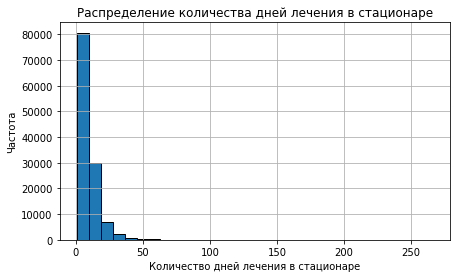

In [24]:
plt.figure(figsize=(7, 4))
df_hospital['bed_days'].hist(bins=30, edgecolor='black')
plt.xlabel("Количество дней лечения в стационаре")
plt.ylabel("Частота")
plt.title("Распределение количества дней лечения в стационаре")


plt.show()

Можем сделать выводы:
* большинство пациентов провело меньше 10 дней в стационаре;
* распределение смещено влево (`right-skewed`) – короткие госпитализации встречаются гораздо чаще;
* есть пациенты с пребыванием более 50, 100 и даже 250 дней, но их очень мало;
* это может быть связано с хроническими заболеваниями, реабилитацией или сложными случаями.

Оценим распределение длительности госпитализации пациентов.

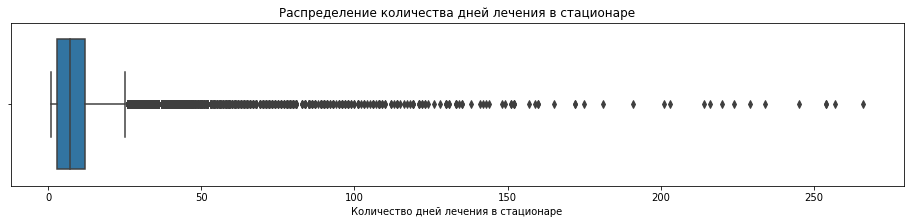

In [25]:
# Построение боксплота для столбца 'Количество дней лечения в стационаре'
plt.figure(figsize=(16, 3))
sns.boxplot(x=df_hospital['bed_days'])

plt.xlabel("Количество дней лечения в стационаре")
plt.title("Распределение количества дней лечения в стационаре")


plt.show()

In [26]:
median_days = df_hospital['bed_days'].median()
mean_days = df_hospital['bed_days'].mean()
q1 = df_hospital['bed_days'].quantile(0.25)
q3 = df_hospital['bed_days'].quantile(0.75)
iqr = q3 - q1
min_days = df_hospital['bed_days'].min()
max_days = df_hospital['bed_days'].max()


print(f"Медиана: {median_days} дней")
print(f"Среднее: {mean_days:.1f} дней (может быть завышено выбросами)")
print(f"25-й перцентиль (Q1): {q1} дней")
print(f"75-й перцентиль (Q3): {q3} дней")
print(f"Межквартильный размах (IQR): {iqr} дней")
print(f"Минимальное значение: {min_days} дней")
print(f"Максимальное значение: {max_days} дней")

Медиана: 7.0 дней
Среднее: 8.7 дней (может быть завышено выбросами)
25-й перцентиль (Q1): 3.0 дней
75-й перцентиль (Q3): 12.0 дней
Межквартильный размах (IQR): 9.0 дней
Минимальное значение: 1 дней
Максимальное значение: 266 дней


Получаем следующие данные:
* половина пациентов проводит в стационаре не более недели;
* среднее значение (8.7 дней) выше медианы, что говорит о наличии выбросов – пациентов, которые находятся в стационаре гораздо дольше;
* 25% пациентов (Q1) проводят ≤ 3 дней в стационаре, что говорит о значительном количестве краткосрочных госпитализаций;
* максимальное значение — 266 дней.

## Средняя длительность госпитализации по отделениям

В некоторых отделениях пациенты находятся дольше. Это может быть связано со спецификой лечения. Выведем среднюю длительность госпитализации по отделениям.

Сгруппируем данные по названию отделения и расчитаем среднее значения длительности госпитализации в каждой группе (отделении). Затем отсортируем отделения по убыванию среднего времени пребывания

In [27]:
dept_stay = df_hospital.groupby("dept")["bed_days"].mean().sort_values(ascending=False)

In [28]:
dept_stay

dept
Отделение анестезиологии-реанимации                                                                          45.179487
ПЦ ОАРИТН №1 (новорожденных)                                                                                 28.723214
ПЦ Отделение Анестезиологии-реанимации для детей с кардиохирургической патологией                            26.438095
ПЦ Отделение патологии новорожденных и детей грудного возраста                                               22.098196
ПЦ Отделение вспомогательных репродуктивных технологий ДС                                                    21.297802
Дневной стационар Кожно-венерологического отделения                                                          14.027322
Дневной стационар Гастроэнтерологического отделения                                                          13.339286
Микрохирургическое отделение                                                                                 13.293007
Педиатрическое отделение №1                

Самые длительные госпитализации наблюдаются в следующих отделениях:

* отделение анестезиологии-реанимации (45.2 дней) – это логично, так как пациенты в реанимации находятся в тяжёлом состоянии и часто требуют интенсивной терапии;
* ПЦ ОАРИТН №1 (новорождённых) – 28.7 дней – новорождённые с осложнениями или недоношенные дети требуют длительного медицинского наблюдения;
* кардиохирургическая реанимация для детей (26.4 дней) – длительный период наблюдения после сложных операций.

Краткосрочные госпитализации (< 5 дней):
* ПЦ ОАРИТ №2 для беременных, рожениц и родильниц (1.5 дня) – вероятно, связано с коротким наблюдением после родов;
* ПЭМП ДПО (1 день) – возможно, это диагностическое отделение или экстренная помощь, где пациенты не задерживаются.

Определим Топ-10 отделений с наибольшей средней длительностью лечения. Оформим результат в виде горизонтального столбчатого графика.

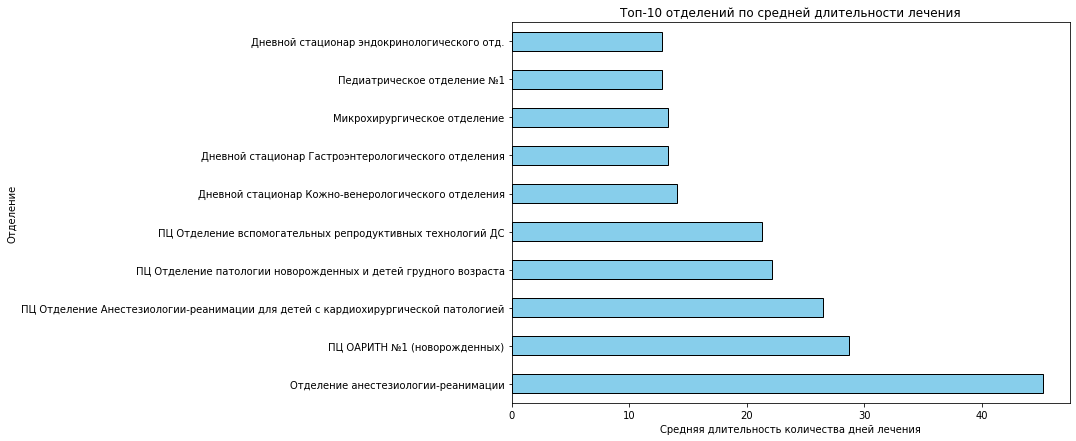

In [29]:
plt.figure(figsize=(10, 7))
dept_stay.head(10).plot(kind='barh', color='skyblue', edgecolor='black')
plt.xlabel("Средняя длительность количества дней лечения")
plt.ylabel("Отделение")
plt.title("Топ-10 отделений по средней длительности лечения")
plt.show()

### В разные годы рассчитать количество поступивших пациентов по месяцам

Добавим столбец с месяцем госпитализации. Преобразуем столбец даты поступления пациента в отделение в формат «год-месяц» и сгруппируем данные по месяцу госпитализации. 

In [30]:
df_hospital["Месяц_госпитализации"] = df_hospital["income_date"].dt.to_period("M")
hospitalizations_over_time = df_hospital.groupby("Месяц_госпитализации")["user_id"].nunique()

Для визуализации можно использовать линейный график.

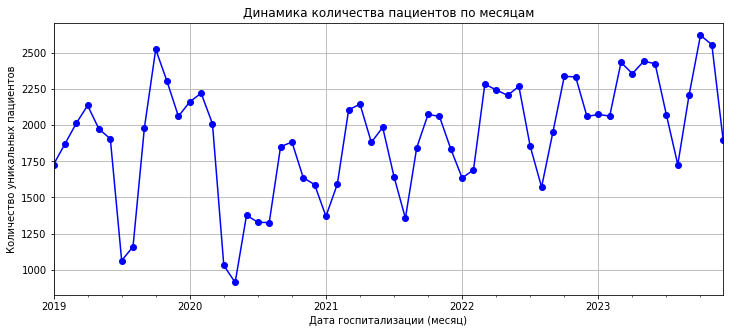

In [31]:
plt.figure(figsize=(12, 5))
hospitalizations_over_time.plot(color='blue', marker='o', linestyle='-')

plt.xlabel("Дата госпитализации (месяц)")
plt.ylabel("Количество уникальных пациентов")
plt.title("Динамика количества пациентов по месяцам")
plt.grid(True)
plt.show()

## Проверка гипотез

### Проверка гипотез с одной выборкой

#### Проверим, отличается ли средняя длительность госпитализации пациентов от стандартного срока в 7 дней.

На основе ранее рассчитанных данных, средняя длительность госпитализации в больницах составляет немного больше 7 дней. Однако есть сомнения в актуальности этой гипотезы, поэтому её стоит проверить.

Средняя длительность госпитализации равна 7 дням (стандартный срок госпитализации).

* 𝐻_0 : Средняя длительность госпитализации в больницах= 7.
* 𝐻_1 : Средняя длительность госпитализации в больницах не равна 7.

Установим параметры, которые будут использоваться для проверки статистической гипотезы:

`expected_mean_time = 7` — это ожидаемое среднее количество дней лечения в
стационаре, с которым вы будете сравнивать реальные данные.
`alpha = 0.05` — уровень статистической значимости (обычно 5%, или 0.05), который определяет границу для принятия или отклонения нулевой гипотезы.

In [32]:
expected_mean_time = 7

alpha = 0.05

results = st.ttest_1samp(
    df_hospital['bed_days'],
    expected_mean_time,
    alternative='two-sided')


print('p-значение:', results.pvalue)

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')

p-значение: 0.0
Отвергаем нулевую гипотезу


Это означает, что у нас недостаточно обоснований, чтобы не отвергнуть нулевую гипотезу. Поэтому с большей вероятностью можно отклонить нулевую гипотезу и сказать, что фактическое среднее время госпитализации в больнице значимо отличается от  7 дней.

## Проверим,  превышает ли средняя длительность госпитализации пациентов 10 дней

* H_0: Средняя длительность госпитализации в больницах = 10.
* H_1: Средняя длительность госпитализации в больницах > 10

In [33]:
expected_mean_price = 10
alpha = 0.05

results = st.ttest_1samp(
    df_hospital['bed_days'],
    expected_mean_price,
    alternative='greater')


print('p-значение:', results.pvalue)

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')

p-значение: 1.0
Не получилось отвергнуть нулевую гипотезу


In [34]:
df_hospital['bed_days'].mean()

8.728508060511768

Видно, что p-значение очень большое, а это значит что отвергнуть нулевую гипотезу не получилось. Следовательно, нельзя утверждать, что средняя длительность госпитализации пациентов статистически значимо превышает 10 дней.

### Проверка гипотез с двумя выборками

Изучим, различается ли средняя продолжительность лечения в стационаре между плановыми и экстренными пациентами?

* 𝐻_0 : Среднее количество дней лечения в стационаре отличается между плановыми и экстренными пациентами одинаково.
* 𝐻_1 : Среднее количество дней лечения в стационаре отличается между плановыми и экстренными пациентами различается.

In [35]:
plan_group = df_hospital[df_hospital["is_plan"] == "Плановая"]["bed_days"]
urgent_group = df_hospital[df_hospital["is_plan"] == "Экстренная"]["bed_days"]

In [36]:
plan_group.mean()

9.716638313138677

In [37]:
urgent_group.mean()

6.248380631481105

Время пребывания очень разное. После экстренной госпитализации человек в среднем задерживается на 3 дня меньше.

In [38]:
alpha = 0.05

results = st.ttest_ind(
    plan_group,
    urgent_group,
    alternative='two-sided')


print('p-значение:', results.pvalue)

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')

p-значение: 0.0
Отвергаем нулевую гипотезу


Таким образом, нельзя говорить, что среднее количество дней лечения в стационаре отличается между плановыми и экстренными пациентами одинаково. С точки зрения статистики, разница недостаточно значима.

## Выводы

Анализ распределения количества дней лечения в стационаре с помощью гистограммы показал, что большинство пациентов пребывают в больнице относительно недолго. Ту же тенденцию подтвердил box plot. Поэтому для нормального функционирования отделений важно было проверить гипотезу: действительно ли средняя продолжительность госпитализации равна неделе?

Вы сравнили среднее по выборке с определённым числом, используя  одновыборочный t-тест Стьюдента. В результате теста нулевая гипотеза была отвергнута.

Для анализа максимальной загрузки коечного фонда была проверена гипотеза: превышает ли средняя продолжительность госпитализации 10 дней.
В этом случае нулевая гипотеза не была отвергнута. Это означает, что нет достаточных статистических оснований утверждать, что среднее время пребывания пациентов превышает 10 дней. Это говорит о том, что текущая средняя продолжительность госпитализации не создаёт значительных рисков переполнения стационара.

Кроме того нужно было проверить гипотезу, которая затрагивала экстренную и плановую госпитализации. Визуально (например, по средним значениям) разница есть, но важно понять, насколько она значима с точки зрения статистики. Для сравнения двух независимых групп применили t-тест Стьюдента для двух выборок.

Уровень значимости задали в 5%. То есть приняли 5%-ный риск сделать ошибку, если в действительности разницы между группами нет. Другими словами, в 5 случаях из 100 можно случайно обнаружить различие, которого на самом деле нет.

**Как это влияет на решение**
* Если p-value (результат статистического теста) меньше 0.05 - отвергаем нулевую гипотезу, считаем различие статистически значимым.
* Если p-value больше 0.05 - недостаточно данных, чтобы отвергнуть нулевую гипотезу.

Вы сравнили среднюю длительность госпитализации между экстренными и плановыми пациентами.
Получили p-value < 0.05, что говорит о значимых различиях между группами.
Это значит, что вероятность того, что разница между средними значениями случайна, меньше 5%. Таким образом, мы отвергаем нулевую гипотезу и утверждаем, что различие между средними значениями групп существует.

Эти результаты можно использовать для оптимизации коечного фонда и планирования загрузки стационара.